# xG Tutorial — SkillCorner edition


## 0. Setup — libraries, toggles, and pitch helpers


In [15]:
from pathlib import Path
import json
import os
import sys
import urllib.request as request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# ===== Data source toggle =====
DATA_SOURCE = "opendata"   # "opendata" (public 10-match sample) or "local" (your SkillCorner bundle)

# Local SkillCorner bundle settings. You can also set SKILLCORNER_ROOT in your environment.
LOCAL_SKILLCORNER_ROOT = os.environ.get("SKILLCORNER_ROOT")
LOCAL_SKILLCORNER_ROOT = Path(LOCAL_SKILLCORNER_ROOT) if LOCAL_SKILLCORNER_ROOT else None
LOCAL_SEASON_NAMES = None              # e.g. ["2023", "2024", "2025"]
LOCAL_LIMIT_MATCHES = None             # e.g. 50 for a quick run
LOCAL_LIMIT_MATCHES_PER_SEASON = None  # e.g. 120 for balanced season samples
LOCAL_SHOTS_PARQUET = os.environ.get("SKILLCORNER_XG_SHOTS_PARQUET")
LOCAL_SHOTS_PARQUET = Path(LOCAL_SHOTS_PARQUET) if LOCAL_SHOTS_PARQUET else None

# Standard full-size pitch in metres. Coordinates are centre-origin and attack toward +x.
PITCH_X, PITCH_Y = 105.0, 68.0
GOAL_X, GOAL_Y = PITCH_X / 2.0, 0.0
GOAL_WIDTH = 7.32

# Repository root and import path.
root = Path.cwd().resolve()
for p in [root, *root.parents]:
    if (p / "xg").exists() and (p / "xpass").exists():
        root = p
        break
for p in [root, root / "football-cdf"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

OPENDATA_BASE = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches"
OPENDATA_MATCH_IDS = [1886347, 1899585, 1925299, 1953632, 1996435,
                      2006229, 2011166, 2013725, 2015213, 2017461]
OPENDATA_CACHE = root / "tmp/data/skillcorner_opendata"


def require_local_root() -> Path:
    if LOCAL_SKILLCORNER_ROOT is None:
        raise ValueError(
            "Set LOCAL_SKILLCORNER_ROOT or the SKILLCORNER_ROOT environment variable "
            "when DATA_SOURCE='local'."
        )
    return Path(LOCAL_SKILLCORNER_ROOT)


# Plotting helpers: centre-origin -> mplsoccer custom pitch display coordinates.
def to_px(x): return np.asarray(x, dtype=float) + PITCH_X / 2.0
def to_py(y): return np.asarray(y, dtype=float) + PITCH_Y / 2.0


def new_pitch(half=True, figsize=(8.0, 5.2)):
    pitch = Pitch(pitch_type="custom", pitch_length=PITCH_X, pitch_width=PITCH_Y,
                  half=half, pitch_color="none", line_color="#3b3b3b", linewidth=1.4,
                  goal_type="box", corner_arcs=True, line_zorder=2)
    fig, ax = pitch.draw(figsize=figsize)
    return pitch, fig, ax


print("DATA_SOURCE =", DATA_SOURCE)


DATA_SOURCE = opendata


## 1. Build a shot table from SkillCorner Dynamic Events

SkillCorner provides one **Dynamic Events** table per match. For xG, the shot rows are selected with the same rule used by `xg.skillcorner_shots._prepare_match_shots`:

- **Shot selection:** `event_type == "player_possession"` and `end_type == "shot"`.
- **Coordinates:** use `x_end`, `y_end`, then rescale from the match metadata pitch size to 105 x 68 m.
- **Target label:** `game_interruption_after == "goal_for"`.
- Keep useful context such as `is_header`, `start_type`, `player_name`, and `period`.


### 1-1. Inspect one raw Dynamic Events match

Before extracting shots, inspect what the raw event table looks like. The columns we need most are:

- `event_type` / `end_type`: action type.
- `x_start, y_start` / `x_end, y_end`: start and end locations in centre-origin coordinates.
- `game_interruption_after`: whether the possession ended with a goal.
- `is_header`, `start_type`, `player_name`, `period`: context features used later.


In [16]:
# Read one match as (events, pitch_length, pitch_width).
def opendata_match(mid):
    OPENDATA_CACHE.mkdir(parents=True, exist_ok=True)
    base = f"{OPENDATA_BASE}/{mid}"
    ev_path = OPENDATA_CACHE / f"{mid}_dynamic_events.csv"
    mj_path = OPENDATA_CACHE / f"{mid}_match.json"
    if not ev_path.exists():
        request.urlretrieve(f"{base}/{mid}_dynamic_events.csv", ev_path)
    if not mj_path.exists():
        request.urlretrieve(f"{base}/{mid}_match.json", mj_path)
    meta = json.load(open(mj_path))
    events = pd.read_csv(ev_path, low_memory=False)
    return events, float(meta["pitch_length"]), float(meta["pitch_width"])


def local_match(match_id=None):
    from xg.skillcorner_shots import load_match_index, resolve_match_context
    idx = load_match_index(require_local_root(), season_names=LOCAL_SEASON_NAMES)
    if LOCAL_LIMIT_MATCHES is not None:
        idx = idx.head(int(LOCAL_LIMIT_MATCHES))
    row = idx.iloc[0] if match_id is None else idx[idx["match_id"].eq(str(match_id))].iloc[0]
    ctx = resolve_match_context(require_local_root(), row["match_id"], match_dir=row.get("match_dir"))
    events = pd.read_csv(ctx.event_path, low_memory=False)
    meta = ctx.match_metadata
    return events, float(meta["pitch_length"]), float(meta["pitch_width"]), str(row["match_id"])


# Load one example match.
if DATA_SOURCE == "opendata":
    ev, pl, pw = opendata_match(OPENDATA_MATCH_IDS[0])
    ex_label = f"open data {OPENDATA_MATCH_IDS[0]}"
elif DATA_SOURCE == "local":
    ev, pl, pw, ex_id = local_match()
    ex_label = f"local SkillCorner {ex_id}"
else:
    raise ValueError("DATA_SOURCE must be 'opendata' or 'local'")

print(f"{ex_label}: {len(ev):,} events x {ev.shape[1]} columns | pitch {pl} x {pw}")

peek = ["event_type", "end_type", "x_start", "y_start", "x_end", "y_end",
        "player_name", "period", "game_interruption_after"]
display(ev[[c for c in peek if c in ev.columns]].head(10))

print("Top event_type values:")
display(ev["event_type"].value_counts().head(8))
print("Top player_possession end_type values; shots are end_type == 'shot':")
display(ev.loc[ev["event_type"].eq("player_possession"), "end_type"].value_counts().head(10))


open data 1886347: 5,079 events x 294 columns | pitch 104.0 x 68.0


,event_type,end_type,x_start,y_start,x_end,y_end,player_name,period,game_interruption_after
0,player_possession,pass,0.73,0.49,0.73,0.49,B. Gibson,1,NaN
1,player_possession,pass,-22.31,1.22,-22.21,2.70,A. Šušnjar,1,NaN
2,passing_option,NaN,-10.47,-2.78,-11.36,-1.38,K. Grozos,1,NaN
3,passing_option,NaN,-20.69,16.66,-20.36,17.69,M. Natta,1,NaN
4,on_ball_engagement,NaN,13.03,0.06,13.98,-0.68,J. Brimmer,1,NaN
5,player_possession,pass,-17.60,20.17,-10.75,24.18,M. Natta,1,free_kick_against
6,passing_option,NaN,-4.66,11.04,-6.39,14.27,C. Timmins,1,NaN
7,passing_option,NaN,14.93,10.13,11.67,16.14,L. Bayliss,1,NaN
8,passing_option,NaN,12.73,3.61,16.91,9.27,B. Gibson,1,NaN
9,passing_option,NaN,7.31,19.98,6.87,27.64,T. Aquilina,1,NaN


Top event_type values:


event_type
passing_option        2544
player_possession      999
on_ball_engagement     937
off_ball_run           599
Name: count, dtype: int64

Top player_possession end_type values; shots are end_type == 'shot':


end_type
pass               902
possession_loss     48
shot                23
foul_suffered       15
clearance            9
unknown              2
Name: count, dtype: int64

### 1-2. Extract shot rows

Now select shot possessions, rescale coordinates to 105 x 68 m, and attach the `goal` label.


example match: open data 1886347 | shots 23 | goals 2


,shot_x,shot_y,goal,is_header,start_type
166,40.071635,5.23,False,False,pass_reception
515,27.592788,-1.29,False,False,pass_reception
653,45.341827,15.32,False,False,pass_reception
1251,29.480769,13.66,False,False,pass_reception
1342,32.075481,17.06,False,False,keep_possession
1414,26.643750,-10.05,False,False,recovery
1456,47.058173,10.19,False,False,unknown
1646,40.828846,4.59,False,False,pass_reception


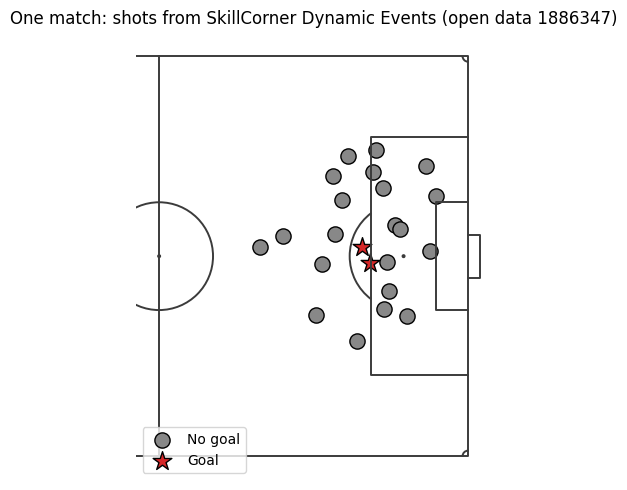

In [17]:
# Core transformation: Dynamic Events DataFrame -> shot table.
def shots_from_events(events, pitch_length, pitch_width):
    sh = events[(events["event_type"] == "player_possession")
                & (events["end_type"] == "shot")].copy()
    sx, sy = PITCH_X / float(pitch_length), PITCH_Y / float(pitch_width)
    sh["shot_x"] = pd.to_numeric(sh["x_end"], errors="coerce") * sx
    sh["shot_y"] = pd.to_numeric(sh["y_end"], errors="coerce") * sy
    sh["possession_start_x"] = pd.to_numeric(sh["x_start"], errors="coerce") * sx
    sh["possession_start_y"] = pd.to_numeric(sh["y_start"], errors="coerce") * sy
    if "game_interruption_after" in sh.columns:
        sh["goal"] = sh["game_interruption_after"].eq("goal_for")
    else:
        sh["goal"] = sh.get("lead_to_goal", pd.Series(False, index=sh.index)).fillna(False).astype(bool)
    if "is_header" in sh.columns:
        sh["is_header"] = sh["is_header"].fillna(False).astype(bool)
    else:
        sh["is_header"] = False
    return sh


ms = shots_from_events(ev, pl, pw)
print(f"example match: {ex_label} | shots {len(ms)} | goals {int(ms['goal'].sum())}")
display(ms[["shot_x", "shot_y", "goal", "is_header", "start_type"]].head(8))

pitch, fig, ax = new_pitch(half=True, figsize=(7.5, 5))
g = ms["goal"].astype(bool)
pitch.scatter(to_px(ms.loc[~g, "shot_x"]), to_py(ms.loc[~g, "shot_y"]),
              ax=ax, s=120, c="#888888", edgecolors="black", label="No goal")
pitch.scatter(to_px(ms.loc[g, "shot_x"]), to_py(ms.loc[g, "shot_y"]),
              ax=ax, s=200, marker="*", c="#d62728", edgecolors="black", label="Goal")
ax.legend(loc="lower left"); ax.set_title(f"One match: shots from SkillCorner Dynamic Events ({ex_label})")
plt.show()


### 1-3. Expand to all matches

Repeating the transformation for every match gives the modelling table.

- `opendata`: download, transform, and concatenate the 10 public matches. Because this is one season, the model uses a match-level split.
- `local`: either load a prebuilt parquet table or build from your local SkillCorner root. With multiple seasons, the model can use a season-level split.


In [18]:
if DATA_SOURCE == "opendata":
    frames = []
    for mid in OPENDATA_MATCH_IDS:
        ev_i, pl_i, pw_i = opendata_match(mid)
        sh_i = shots_from_events(ev_i, pl_i, pw_i)
        sh_i["match_id"] = str(mid)
        sh_i["season_name"] = "2024/2025"
        frames.append(sh_i)
    shots = pd.concat(frames, ignore_index=True)
    USE_SEASON_SPLIT = False
else:
    if LOCAL_SHOTS_PARQUET is not None:
        shots = pd.read_parquet(LOCAL_SHOTS_PARQUET)
    else:
        from xg.skillcorner_shots import build_skillcorner_shot_table
        shots = build_skillcorner_shot_table(
            require_local_root(),
            season_names=LOCAL_SEASON_NAMES,
            limit_matches=LOCAL_LIMIT_MATCHES,
            limit_matches_per_season=LOCAL_LIMIT_MATCHES_PER_SEASON,
        )
    USE_SEASON_SPLIT = True

shots = shots.dropna(subset=["shot_x", "shot_y"]).copy()
shots["goal"] = shots["goal"].astype(bool)
if "is_header" not in shots.columns:
    shots["is_header"] = False
if "season_name" not in shots.columns:
    shots["season_name"] = "local"
print(f"{len(shots):,} shots | matches {shots['match_id'].nunique()} | "
      f"seasons {sorted(shots['season_name'].astype(str).unique())} | season-split={USE_SEASON_SPLIT}")
shots[["season_name", "match_id", "shot_x", "shot_y", "is_header", "goal"]].head()


226 shots | matches 10 | seasons ['2024/2025'] | season-split=False


,season_name,match_id,shot_x,shot_y,is_header,goal
0,2024/2025,1886347,40.071635,5.23,False,False
1,2024/2025,1886347,27.592788,-1.29,False,False
2,2024/2025,1886347,45.341827,15.32,False,False
3,2024/2025,1886347,29.480769,13.66,False,False
4,2024/2025,1886347,32.075481,17.06,False,False


## 2. Explore the data

Each row is one shot. The target is `goal`; the core inputs are `shot_x` and `shot_y`.


Overall goal rate: 0.115


season_name
2024/2025    226
Name: shots, dtype: int64

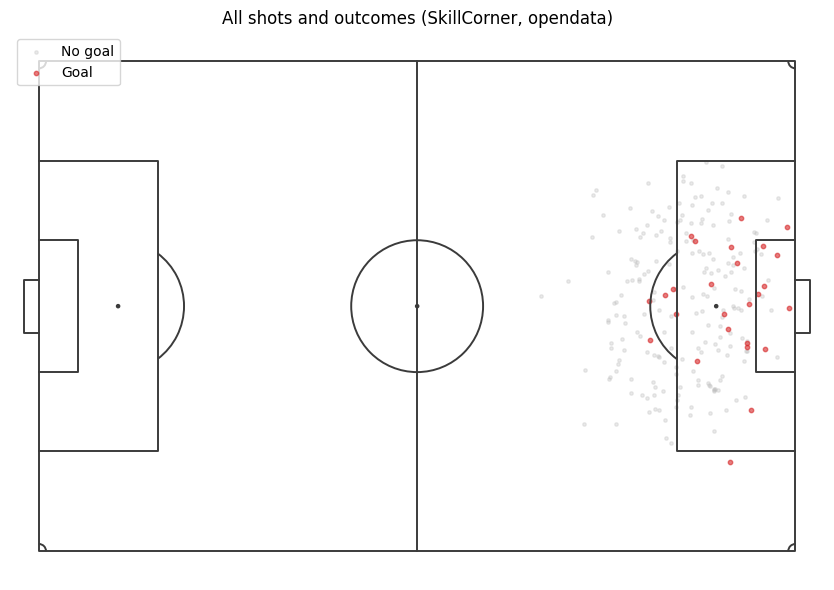

In [19]:
print("Overall goal rate:", round(shots["goal"].mean(), 4))
display(shots["season_name"].astype(str).value_counts().sort_index().rename("shots"))

pitch, fig, ax = new_pitch(half=False, figsize=(9, 6))
g = shots["goal"].astype(bool)
pitch.scatter(to_px(shots.loc[~g, "shot_x"]), to_py(shots.loc[~g, "shot_y"]),
              ax=ax, s=6, c="#bcbcbc", alpha=0.3, label="No goal")
pitch.scatter(to_px(shots.loc[g, "shot_x"]), to_py(shots.loc[g, "shot_y"]),
              ax=ax, s=10, c="#d62728", alpha=0.6, label="Goal")
ax.legend(loc="upper left"); ax.set_title(f"All shots and outcomes (SkillCorner, {DATA_SOURCE})")
plt.show()


## 3. Core intuition — location drives goal probability

The starting point for xG is simple: among shots taken from similar locations, how often did they become goals? We aggregate by distance bins and location bins to build the most primitive version of an xG map.


,shots,goal_rate
distance_to_goal,,
"(0, 6]",6,0.500
"(6, 11]",36,0.250
"(11, 16]",44,0.136
"(16, 23]",86,0.081
"(23, 40]",54,0.019


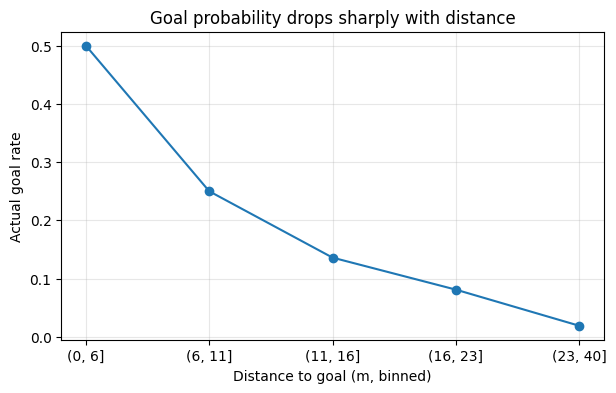

In [20]:
shots["distance_to_goal"] = np.hypot(GOAL_X - shots["shot_x"], GOAL_Y - shots["shot_y"])

bins = [0, 6, 11, 16, 23, 40]
by_dist = (shots.groupby(pd.cut(shots["distance_to_goal"], bins), observed=True)["goal"]
                 .agg(shots="size", goal_rate="mean").round(3))
display(by_dist)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([str(i) for i in by_dist.index], by_dist["goal_rate"], marker="o", color="#1f77b4")
ax.set_xlabel("Distance to goal (m, binned)"); ax.set_ylabel("Actual goal rate")
ax.set_title("Goal probability drops sharply with distance"); ax.grid(alpha=0.3)
plt.show()

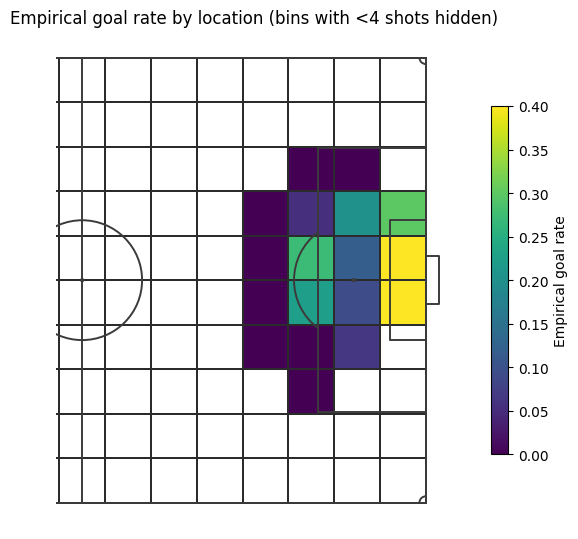

In [21]:
# Empirical goal rate by location. Hide bins with too few shots.
pitch, fig, ax = new_pitch(half=True, figsize=(8, 5.5))
px, py = to_px(shots["shot_x"]), to_py(shots["shot_y"])
gv = shots["goal"].astype(float).to_numpy()
min_count = 20 if DATA_SOURCE == "local" else 4
mean_stat = pitch.bin_statistic(px, py, values=gv, statistic="mean", bins=(15, 10))
cnt_stat  = pitch.bin_statistic(px, py, values=gv, statistic="count", bins=(15, 10))
mean_stat["statistic"] = np.where(cnt_stat["statistic"] < min_count, np.nan, mean_stat["statistic"])
pcm = pitch.heatmap(mean_stat, ax=ax, cmap="viridis", vmin=0, vmax=0.4, edgecolors="#2b2b2b", lw=0.25, zorder=1)
fig.colorbar(pcm, ax=ax, shrink=0.7, label="Empirical goal rate")
ax.set_title(f"Empirical goal rate by location (bins with <{min_count} shots hidden)")
plt.show()


## 4. Build features by hand — distance and angle

1. **Distance to goal:** closer shots should have higher goal probability.
2. **Open angle to goal:** the angle between vectors from the shot location to the two posts.

SkillCorner coordinates are already centre-origin and attacking left-to-right, so no sign flip is needed. The formula matches `xg.xg_features.shot_angle_to_goal`.


In [22]:
def shot_angle(shot_x, shot_y):
    # Open angle to the goal mouth in radians. Larger means more of the goal is visible.
    x = pd.to_numeric(shot_x, errors="coerce").to_numpy(float)
    y = pd.to_numeric(shot_y, errors="coerce").to_numpy(float)
    post_top = np.column_stack([GOAL_X - x,  GOAL_WIDTH / 2 - y])
    post_bot = np.column_stack([GOAL_X - x, -GOAL_WIDTH / 2 - y])
    dot = (post_top * post_bot).sum(axis=1)
    denom = np.linalg.norm(post_top, axis=1) * np.linalg.norm(post_bot, axis=1)
    cos = np.divide(dot, denom, out=np.full_like(dot, np.nan), where=denom > 0)
    return np.arccos(np.clip(cos, -1.0, 1.0))


shots["shot_angle"] = shot_angle(shots["shot_x"], shots["shot_y"])
shots["shot_angle_deg"] = np.degrees(shots["shot_angle"])
display(shots[["shot_x", "shot_y", "distance_to_goal", "shot_angle_deg", "goal"]].head())


,shot_x,shot_y,distance_to_goal,shot_angle_deg,goal
0,40.071635,5.23,13.483960,28.376418,False
1,27.592788,-1.29,24.940595,16.675878,False
2,45.341827,15.32,16.909815,10.882504,False
3,29.480769,13.66,26.767155,13.477268,False
4,32.075481,17.06,26.612114,12.143618,False


## 5. Train an xG model — XGBoost with distance and angle

We use **XGBoost**, a gradient boosting tree model. It captures nonlinear distance/angle effects and interactions without manual polynomial terms. Since it is not a linear model, we inspect **feature importance** instead of coefficients.

The settings mirror the reusable xG training code: shallow trees, regularization, and conservative learning rates. For the very small public Open Data sample, the settings are relaxed so trees can still split.

Train/test split:

- `local` with multiple seasons: train on earlier seasons and test on the last season.
- `opendata` or any single-season sample: split by match so the same match does not appear in both train and test.


In [23]:
from xgboost import XGBClassifier


def make_xgb(n_train):
    # The reusable xG trainer uses the larger-data settings below. For the tiny
    # public Open Data sample, relax the model so it can still make useful splits.
    small = n_train < 2000
    return XGBClassifier(
        n_estimators=300 if small else 450,
        max_depth=3,
        learning_rate=0.05 if small else 0.035,
        subsample=0.9 if small else 0.85,
        colsample_bytree=0.9 if small else 0.85,
        min_child_weight=1 if small else 8,
        reg_lambda=1.0 if small else 2.0,
        objective="binary:logistic", eval_metric="logloss",
        n_jobs=4, random_state=42, tree_method="hist",
    )


seasons = sorted(shots["season_name"].astype(str).unique())
if USE_SEASON_SPLIT and len(seasons) >= 2:
    test_season = seasons[-1]
    train_mask = shots["season_name"].astype(str).ne(test_season)
    test_mask  = shots["season_name"].astype(str).eq(test_season)
    split_desc = f"train seasons {seasons[:-1]} / test season {test_season}"
else:
    match_ids = sorted(shots["match_id"].astype(str).unique())
    n_test = max(1, len(match_ids) // 3)
    test_ids = set(match_ids[-n_test:])
    test_mask  = shots["match_id"].astype(str).isin(test_ids)
    train_mask = ~test_mask
    split_desc = f"train {len(match_ids) - n_test} matches / test {n_test} matches (single season)"

print(split_desc)
print(f"train {int(train_mask.sum()):,} shots / test {int(test_mask.sum()):,} shots")

feat_simple = ["distance_to_goal", "shot_angle"]
m1 = make_xgb(int(train_mask.sum()))
m1.fit(shots.loc[train_mask, feat_simple], shots.loc[train_mask, "goal"].astype(int))
print("\nfeature importance:")
for f, imp in sorted(zip(feat_simple, m1.feature_importances_), key=lambda t: -t[1]):
    print(f"  {f:18s} {imp:.3f}")

shots["xg_simple"] = np.nan
shots.loc[test_mask, "xg_simple"] = m1.predict_proba(shots.loc[test_mask, feat_simple])[:, 1]


train 7 matches / test 3 matches (single season)
train 156 shots / test 70 shots

feature importance:
  shot_angle         0.539
  distance_to_goal   0.461


## 6. Evaluate probability quality, not accuracy

Goals are rare, so a model can be highly accurate by predicting "no goal" almost everywhere. xG is a probability model, so we evaluate **log loss, Brier score, AUC, and total predicted xG vs actual goals**.


In [24]:
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

def report(y, p, name):
    y = np.asarray(y, dtype=int); p = np.asarray(p, dtype=float)
    print(f"{name:22s} log_loss={log_loss(y, p, labels=[0,1]):.4f}  "
          f"Brier={brier_score_loss(y, p):.4f}  AUC={roc_auc_score(y, p):.4f}  "
          f"sum(xG)={p.sum():6.1f}  goals={int(y.sum())}")

y_test = shots.loc[test_mask, "goal"].astype(int)
report(y_test, shots.loc[test_mask, "xg_simple"], "distance + angle")
baseline = np.full(int(test_mask.sum()), shots.loc[train_mask, "goal"].mean())
report(y_test, baseline, "baseline (constant)")

distance + angle       log_loss=0.3862  Brier=0.1129  AUC=0.7268  sum(xG)=   8.0  goals=8
baseline (constant)    log_loss=0.3554  Brier=0.1012  AUC=0.5000  sum(xG)=   8.1  goals=8


## 7. Calibration

A well-calibrated xG model should satisfy: shots predicted around 0.20 xG should score about 20% of the time. We bin predictions and compare mean predicted xG with the actual goal rate.


,shots,pred_xg,goal_rate
0,25,0.007,0.000
1,21,0.033,0.143
2,24,0.299,0.208


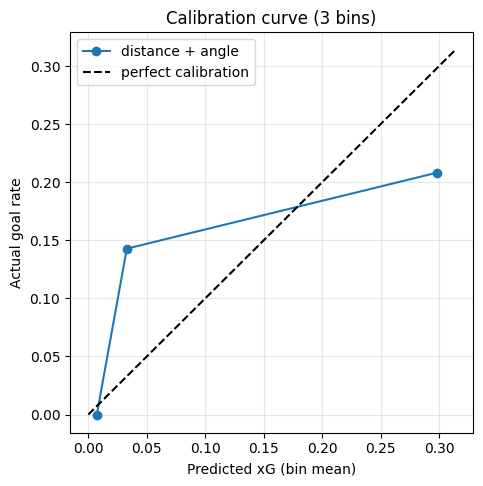

In [25]:
def calibration_table(y, p, q):
    d = pd.DataFrame({"y": np.asarray(y, dtype=int), "p": np.asarray(p, dtype=float)})
    d["bin"] = pd.qcut(d["p"], q, duplicates="drop")
    return (d.groupby("bin", observed=True)
              .agg(shots=("y", "size"), pred_xg=("p", "mean"), goal_rate=("y", "mean"))
              .reset_index(drop=True))


n_bins = min(10, max(3, int(test_mask.sum()) // 40))
cal = calibration_table(y_test, shots.loc[test_mask, "xg_simple"], n_bins)
display(cal.round(3))

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot(cal["pred_xg"], cal["goal_rate"], "o-", color="#1f77b4", label="distance + angle")
lim = float(cal[["pred_xg", "goal_rate"]].max().max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", label="perfect calibration")
ax.set_xlabel("Predicted xG (bin mean)"); ax.set_ylabel("Actual goal rate")
ax.set_title(f"Calibration curve ({n_bins} bins)"); ax.legend(); ax.grid(alpha=0.3)
plt.show()


## 8. Add richer SkillCorner features and compare xG surfaces

First add a compact location/header model so the learned surface can be plotted directly. Then reuse the package feature pipeline from `xg.xg_features` and `xg.train_skillcorner_xg`, which keeps this tutorial aligned with the reusable open-source code.

The public Open Data sample is intentionally small, so the module-rich example uses the logistic pipeline there. The production XGBoost pipeline is still available for larger local SkillCorner datasets, but on a tiny sample its stronger regularization can collapse to almost constant predictions: good-looking log loss, but AUC near 0.5 because it does not rank shots.

For visualization, compare a smooth `distance + angle` logistic surface with the compact XGBoost surface. The logistic surface is the safer tutorial reference; the tree surface is useful for showing how flexible models can become blocky and non-monotonic on small samples.


In [26]:
shots["in_box"] = ((shots["shot_x"] >= GOAL_X - 16.5) & (shots["shot_y"].abs() <= 20.16)).astype(int)
shots["is_header_i"] = shots["is_header"].astype("boolean").fillna(False).astype(int)

feat_rich = ["distance_to_goal", "shot_angle", "in_box", "is_header_i"]
m2 = make_xgb(int(train_mask.sum()))
m2.fit(shots.loc[train_mask, feat_rich], shots.loc[train_mask, "goal"].astype(int))
shots.loc[test_mask, "xg_rich"] = m2.predict_proba(shots.loc[test_mask, feat_rich])[:, 1]

from xg.xg_features import TARGET_COLUMN as XG_TARGET_COLUMN, add_xg_features, get_model_feature_columns as get_xg_feature_columns
from xg.train_skillcorner_xg import make_xg_pipeline

shots_featured = add_xg_features(shots)
xg_numeric, xg_binary, xg_categorical = get_xg_feature_columns()
xg_module_features = xg_numeric + xg_binary + xg_categorical
for col in xg_binary:
    shots_featured[col] = shots_featured[col].astype(float)
for col in xg_categorical:
    shots_featured[col] = shots_featured[col].astype("string").fillna("missing")
shots_featured[XG_TARGET_COLUMN] = shots_featured[XG_TARGET_COLUMN].astype(bool)

# The reusable XGBoost settings are tuned for larger datasets. On the tiny
# public Open Data tutorial sample, use the module logistic pipeline so the rich
# feature example remains informative instead of becoming a constant predictor.
module_model_name = "logistic" if int(train_mask.sum()) < 2000 else "xgboost"
m3 = make_xg_pipeline(module_model_name)
m3.fit(shots_featured.loc[train_mask, xg_module_features],
       shots_featured.loc[train_mask, XG_TARGET_COLUMN].astype(int))
shots.loc[test_mask, "xg_module_rich"] = m3.predict_proba(shots_featured.loc[test_mask, xg_module_features])[:, 1]

report(y_test, shots.loc[test_mask, "xg_simple"], "distance + angle")
report(y_test, shots.loc[test_mask, "xg_rich"], "+ in_box / header")
report(y_test, shots.loc[test_mask, "xg_module_rich"], f"module rich ({module_model_name})")

available_numeric = [c for c in xg_numeric if c in shots_featured.columns and shots_featured[c].notna().any()]
available_categorical = [c for c in xg_categorical if c in shots_featured.columns and shots_featured[c].notna().any()]
print()
print(f"module feature columns: {len(xg_module_features)} total "
      f"({len(xg_numeric)} numeric, {len(xg_binary)} binary, {len(xg_categorical)} categorical)")
print("numeric inputs populated in this data:", available_numeric)
print("categorical inputs populated in this data:", available_categorical)

pred_diag = shots.loc[test_mask, ["xg_simple", "xg_rich", "xg_module_rich"]].agg(["min", "mean", "std", "max"]).T
print()
print("prediction spread on the test split:")
display(pred_diag.round(4))

print()
print("feature importance (compact rich model):")
for f, imp in sorted(zip(feat_rich, m2.feature_importances_), key=lambda t: -t[1]):
    print(f"  {f:18s} {imp:.3f}")


distance + angle       log_loss=0.3862  Brier=0.1129  AUC=0.7268  sum(xG)=   8.0  goals=8
+ in_box / header      log_loss=0.4225  Brier=0.1128  AUC=0.7228  sum(xG)=   7.9  goals=8
module rich (logistic) log_loss=0.3063  Brier=0.0903  AUC=0.8085  sum(xG)=  10.3  goals=8

module feature columns: 62 total (29 numeric, 22 binary, 11 categorical)
numeric inputs populated in this data: ['shot_x', 'shot_y', 'abs_shot_y', 'distance_to_goal', 'distance_to_goal_sq', 'shot_angle', 'shot_angle_deg', 'shot_angle_sin', 'shot_angle_cos', 'possession_distance_to_shot', 'distance_covered', 'duration', 'speed_avg', 'trajectory_angle', 'pass_distance_received', 'n_passing_options', 'n_off_ball_runs', 'n_passing_options_line_break', 'n_passing_options_ahead', 'last_defensive_line_x_start', 'last_defensive_line_x_end', 'delta_to_last_defensive_line_start', 'delta_to_last_defensive_line_end', 'delta_to_last_defensive_line_gain', 'last_defensive_line_height_start', 'last_defensive_line_height_end', 'last_def

,min,mean,std,max
xg_simple,0.0066,0.1148,0.1710,0.8347
xg_rich,0.0040,0.1133,0.1873,0.7755
xg_module_rich,0.0001,0.1471,0.2062,0.8522



feature importance (compact rich model):
  in_box             0.312
  shot_angle         0.268
  distance_to_goal   0.239
  is_header_i        0.181


surface-model comparison on the same test split:
logistic surface       log_loss=0.2928  Brier=0.0883  AUC=0.8165  sum(xG)=   7.4  goals=8
compact XGBoost        log_loss=0.4225  Brier=0.1128  AUC=0.7228  sum(xG)=   7.9  goals=8


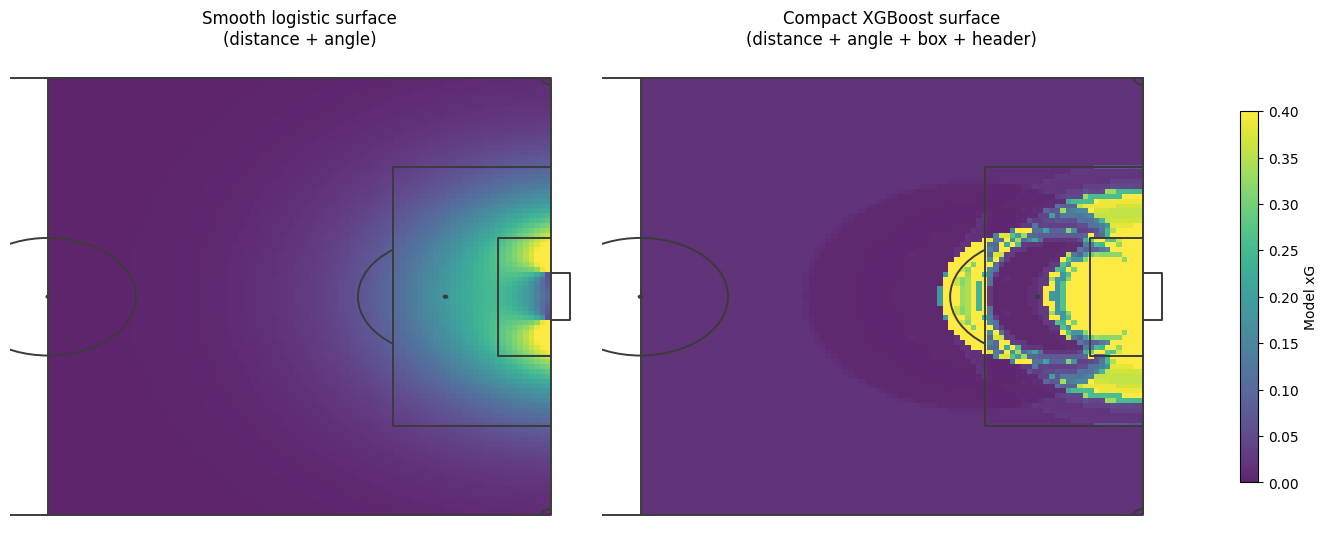

In [28]:
# Compare a smooth logistic reference surface with the compact XGBoost surface.
# The tree model can be useful, but on small samples it can create blocky local artifacts.
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

feat_surface = ["distance_to_goal", "shot_angle"]
surface_logit = Pipeline(steps=[
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs")),
])
surface_logit.fit(shots.loc[train_mask, feat_surface], shots.loc[train_mask, "goal"].astype(int))

shots["xg_surface_logit"] = np.nan
shots.loc[test_mask, "xg_surface_logit"] = surface_logit.predict_proba(shots.loc[test_mask, feat_surface])[:, 1]
print("surface-model comparison on the same test split:")
report(y_test, shots.loc[test_mask, "xg_surface_logit"], "logistic surface")
report(y_test, shots.loc[test_mask, "xg_rich"], "compact XGBoost")

# Apply both trained models to a grid of pitch locations.
gx = np.linspace(0, GOAL_X, 90)
gy = np.linspace(-PITCH_Y / 2, PITCH_Y / 2, 90)
XX, YY = np.meshgrid(gx, gy)
grid = pd.DataFrame({
    "distance_to_goal": np.hypot(GOAL_X - XX, GOAL_Y - YY).ravel(),
    "shot_angle":       shot_angle(pd.Series(XX.ravel()), pd.Series(YY.ravel())),
    "in_box":           ((XX >= GOAL_X - 16.5) & (np.abs(YY) <= 20.16)).astype(int).ravel(),
    "is_header_i":      0,
})
logit_surface = surface_logit.predict_proba(grid[feat_surface])[:, 1].reshape(XX.shape)
tree_surface = m2.predict_proba(grid[feat_rich])[:, 1].reshape(XX.shape)

pitch = Pitch(pitch_type="custom", pitch_length=PITCH_X, pitch_width=PITCH_Y,
              half=True, pitch_color="none", line_color="#3b3b3b", linewidth=1.4,
              goal_type="box", corner_arcs=True, line_zorder=2)
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4), constrained_layout=True)
vmin, vmax = 0.0, 0.40
surfaces = [
    (logit_surface, "Smooth logistic surface\n(distance + angle)"),
    (tree_surface, "Compact XGBoost surface\n(distance + angle + box + header)"),
]
for ax, (surface, title) in zip(axes, surfaces):
    pitch.draw(ax=ax)
    im = ax.imshow(surface,
                   extent=[to_px(0), to_px(GOAL_X), to_py(-PITCH_Y / 2), to_py(PITCH_Y / 2)],
                   origin="lower", cmap="viridis", vmin=vmin, vmax=vmax,
                   alpha=0.86, aspect="auto", zorder=0.5)
    ax.set_title(title)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.76, label="Model xG")
plt.show()
